# Greenland Ice Velocity Sermeq Kujalleq (Ilulissat Glacier) tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021). We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to load and handle a single file in the dataset, using Sermeq Kujalleq (also known as Ilulissat Glacier or Jakobshavn Isbræ) as our example. Sermeq Kujalleq is a fast flowing outlet glacier in West Greenland and has been the focus of lots of work on ice dynamics, including ice velocity analysis. Specifically, we will:
1. Download a NetCDF file from the dataset hosted on the Dataverse portal
2. Visualise velocities over a defined region
3. Return the dataset value at a given point
4. Produce a velocity profile across a flowline

First, let's import all the packages we will be using.

In [89]:
# For data downloading
import requests

# For plotting
import matplotlib.pyplot as plt

# For dataset loading and handling
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree

## 1. Download a NetCDF file from the dataset hosted on the Dataverse portal
The PROMICE Ice Velocity product is available on the [GEUS Dataverse](https://doi.org/10.22008/FK2/LFZLZN). We can download individual files using the requests Python package in a Python console. In this example, we will download a Dataverse file from June/July 2025.

In [102]:
# Define URL to download
URL = "https://dataverse.geus.dk/api/access/datafile/101449"

# Define file location and name
filename = "IV_ROTR_V5_20250621_20250715.nc"

# Start session
SESSION = requests.Session()

# Download file from URL
print(f"Downloading from {URL}...")
r = SESSION.get(URL, stream=True)
r.raise_for_status()
with open(filename, "wb") as f:
    for chunk in r.iter_content(8192):
        f.write(chunk)
print(f"{filename} downloaded")

IV_ROTR_V5_20250621_20250715.nc downloaded


We can open the file and check its contents. To open and handle the file, we will use xarray which is a Python package for handling multi-dimensional arrays. Using a print statement, we can see the dataset coordinates (i.e. time, x, y) and variables (i.e. all the velocity data), along with the dataset attributes (i.e. metadata).

In [119]:
# Open file as xarray dataset
ds = xr.open_dataset(filename)

# Print dataset metadata and overview of contents
print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:                                  (time: 1, bnds: 2, y: 13500,
                                              x: 7500)
Coordinates:
  * time                                     (time) datetime64[ns] 8B 2025-07-03
  * y                                        (y) float64 108kB -6.5e+05 ... -...
  * x                                        (x) float64 60kB -6.5e+05 ... 8....
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S1 1B ...
    time_bnds                                (time, bnds) datetime64[ns] 16B ...
    land_ice_surface_easting_velocity        (time, y, x) float32 405MB ...
    land_ice_surface_northing_velocity       (time, y, x) float32 405MB ...
    land_ice_surface_vertical_velocity       (time, y, x) float32 405MB ...
    land_ice_surface_velocity_magnitude      (time, y, x) float32 405MB ...
    land_ice_surface_easting_velocity_std    (time, y, x) float32 405MB ...
    land_ice_surfa

## 2. Visualize velocities over a defined region
Now we have our file downloaded and checked, let's visualize the dataset over a defined region. Let's visualise the dataset over the region surrounding Sermeq Kujalleq (also known as Ilulissat Glacier or Jakobshavn Isbræ), a fast flowing outlet glacier in West Greenland.

The dataset is projected in EPSG:3413 (WGS 84/NSIDC Sea Ice Polar Stereographic North) with coordinates provided in Latitude/Longitude metres, so we have to provide coordinates in this format for defining our region.


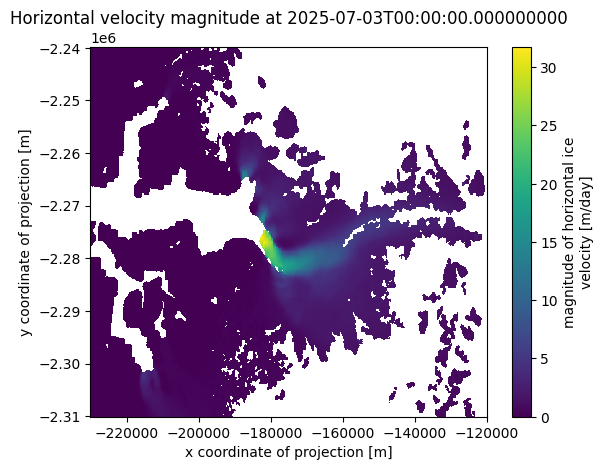

In [124]:
# Extract subset around Sermeq Kujalleq
region = ds.sel(
    x=slice(-230000, -120000),     # lat metres (EPSG:3413)
    y=slice(-2240000, -2310000)    # lon metres (EPSG:3413)
)

# Select horizontal velocity magnitude variable
velocities = region["land_ice_surface_velocity_magnitude"]

# Plot data
plt.figure()
velocities.isel(time=0).plot()
plt.title(f"Horizontal velocity magnitude at {velocities.time.values[0]}")
plt.show()

We can also plot the standard deviation and other variables in the dataset. Let's print a list of the variables in the dataset and then plot the velocity magnitude error magnitude.

In [125]:
# Print list of dataset variables
list(region.variables)

['crs',
 'time_bnds',
 'land_ice_surface_easting_velocity',
 'land_ice_surface_northing_velocity',
 'land_ice_surface_vertical_velocity',
 'land_ice_surface_velocity_magnitude',
 'land_ice_surface_easting_velocity_std',
 'land_ice_surface_northing_velocity_std',
 'land_ice_surface_velocity_magnitude_std',
 'y',
 'x',
 'time']

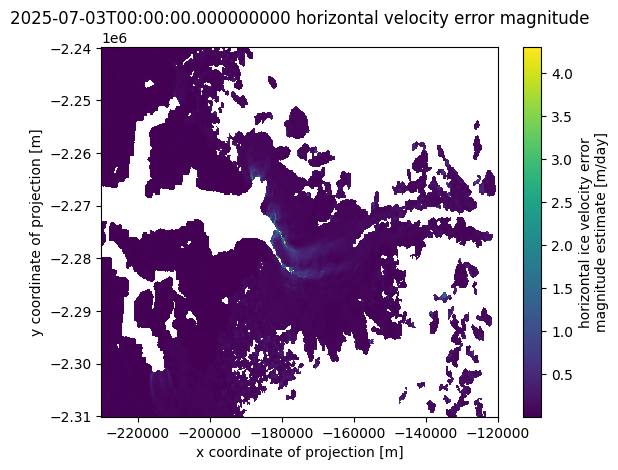

In [126]:
# Select horizontal velocity magnitude error magnitude variable
vel_std = region["land_ice_surface_velocity_magnitude_std"]

# Plot error data
plt.figure()
vel_std.isel(time=0).plot()
plt.title(f"{vel_std.time.values[0]} horizontal velocity error magnitude")
plt.show()

## 3. Return a velocity value at a given point

We can query the dataset and return its values at a given point by providing coordinates. In this example, we will define a point on Sermeq Kujalleq and get the dataset values from the nearest grid point.

In [127]:
# Define point on Sermeq Kujalleq
x = -182284      # lat metres (EPSG:3413)
y = -2276000    # lon metres (EPSG:3413)

# Extract nearest grid point
pt = ds.sel(
    x = x,
    y = y,
    method="nearest"
)

# Print all dataset values at point
for v in list(pt.variables):
    print(f"{v}: {pt[v].values}")

crs: b''
time_bnds: [['2025-06-21T00:00:00.000000000' '2025-07-15T00:00:00.000000000']]
land_ice_surface_easting_velocity: [-21.763367]
land_ice_surface_northing_velocity: [21.740784]
land_ice_surface_vertical_velocity: [-1.0585938]
land_ice_surface_velocity_magnitude: [30.762085]
land_ice_surface_easting_velocity_std: [1.0908203]
land_ice_surface_northing_velocity_std: [0.9394531]
land_ice_surface_velocity_magnitude_std: [1.0439453]
y: -2276000.0
x: -182200.0
time: ['2025-07-03T00:00:00.000000000']


And then we can plot the point location over the dataset, including the velocity magnitude value in the plot title.

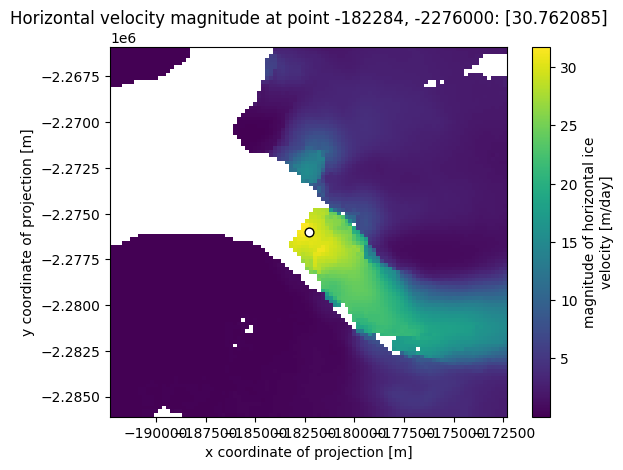

In [128]:
# Prime plotting space
plt.figure()

# Plot velocity magnitude over region, based on point position
pt_region_vel = ds["land_ice_surface_velocity_magnitude"].sel(
    x=slice(x-10000, x+10000),
    y=slice(y+10000, y-10000)
)
pt_region_vel.isel(time=0).plot()

# Plot point
plt.scatter(x, y, c="white", s=40, marker="o", edgecolors="black")

# Construct title including velocity magnitude value
plt.title(f"Horizontal velocity magnitude at point {x}, {y}: {pt['land_ice_surface_velocity_magnitude'].values}")

# Show plot
plt.show()

## 4. Produce a velocity profile along a flowline
Now let's try to generate a velocity profile across a flowline.

This flowline should be a one-dimensional line that represents a glacier's primary path of ice flow. We will firstly make a hypothetical flowline over the catchment of Sermeq Kujalleq. Then we will generate a velocity profile over this flowline, plotting the distance along the flowline versus horizontal velocity magnitude.

Firstly, let's define our flowline as a set of predefined points. Then we will generate evenly spaced points along our flowline, and compute the cumulative distance along this. Note that the number of points you define here can be as long or as short as you like. For this example, we will make our flowline relatively short, covering only a small section of the glacier tongue.

In [129]:
# Define flowline point locations
flowline_x = np.array([-182284, -180000, -177500])
flowline_y = np.array([-2276000, -2279000, -2281000])

dist_flowline = np.zeros(len(flowline_x))
for i in range(1, len(flowline_x)):
    dx = flowline_x[i] - flowline_x[i-1]
    dy = flowline_y[i] - flowline_y[i-1]
    dist_flowline[i] = dist_flowline[i-1] + np.sqrt(dx**2 + dy**2)

# Define number of points along flowline
n_points = 20
even_dist = np.linspace(0, dist_flowline[-1], n_points)

# Interpolate x, y at evenly spaced distances
x_even = np.interp(even_dist, dist_flowline, flowline_x)
y_even = np.interp(even_dist, dist_flowline, flowline_y)

print(x_even)
print(y_even)

[-182284.         -182061.71769005 -181839.43538009 -181617.15307014
 -181394.87076019 -181172.58845023 -180950.30614028 -180728.02383033
 -180505.74152037 -180283.45921042 -180061.17690047 -179792.32184018
 -179505.78161015 -179219.24138013 -178932.70115011 -178646.16092009
 -178359.62069007 -178073.08046004 -177786.54023002 -177500.        ]
[-2276000.         -2276291.96450519 -2276583.92901039 -2276875.89351558
 -2277167.85802077 -2277459.82252596 -2277751.78703116 -2278043.75153635
 -2278335.71604154 -2278627.68054673 -2278919.64505193 -2279166.14252786
 -2279395.37471188 -2279624.60689589 -2279853.83907991 -2280083.07126393
 -2280312.30344795 -2280541.53563196 -2280770.76781598 -2281000.        ]


We can plot our flowline point locations over one of our velocity datasets to see where our velocities will come from.

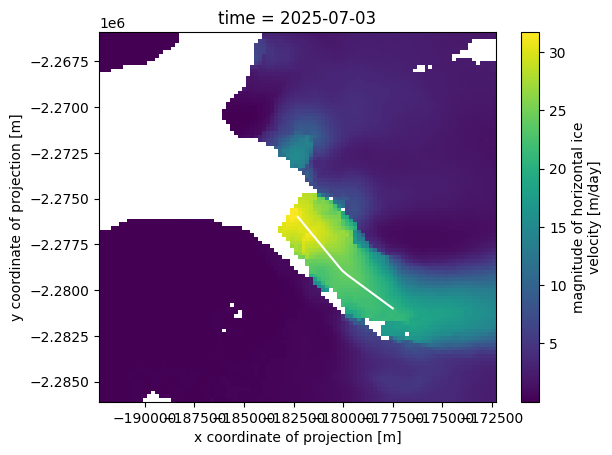

In [130]:
# Plot horizontal velocity magnitude
plt.figure()
pt_region_vel.isel(time=0).plot()

# Overlay point location
plt.plot(x_even,
         y_even,
         c="white"
         )

# Show plot
plt.show()

We can now extract velocity values at the nearest grid points using a nearest neighbour search across flattened grid coordinates in our velocity dataset.

In [131]:
# Flatten grid coordinates
xx, yy = np.meshgrid(pt_region_vel.x.values, pt_region_vel.y.values)
x_grid = xx.ravel()
y_grid = yy.ravel()

# Extract grid of points
vel_data = pt_region_vel.isel(time=0).values.ravel()
valid_mask = ~np.isnan(vel_data)
x_grid = x_grid[valid_mask]
y_grid = y_grid[valid_mask]
vel_data = vel_data[valid_mask]

# Use nearest neighbor search to find coinciding flowline pts
tree = cKDTree(np.column_stack([x_grid, y_grid]))
dist_nn, idx_nn = tree.query(np.column_stack([x_even, y_even]))
vel_profile = vel_data[idx_nn]
print(vel_profile)

[30.762085 30.11676  30.001526 30.839417 29.712524 28.90216  27.055115
 25.94336  24.66681  24.598022 24.248474 24.111206 23.885193 23.355347
 22.769653 22.015137 21.766724 21.022583 20.771118 20.62384 ]


And then we can plot our velocity profile along the flowline, specifically plotting distance along the flowline versus velocity.

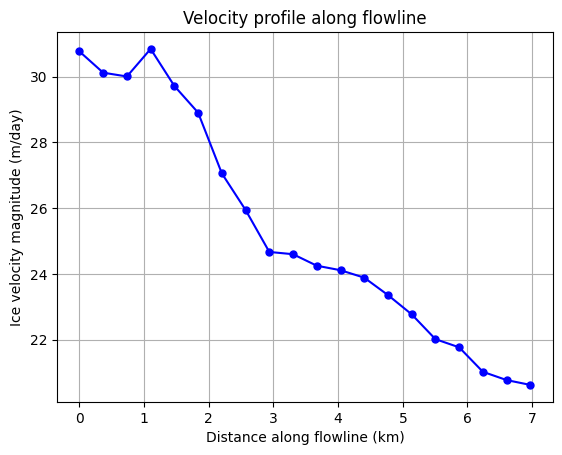

In [132]:
plt.figure()
plt.plot(even_dist/1000, vel_profile, '-o', color='blue', markersize=5)
plt.xlabel("Distance along flowline (km)")
plt.ylabel("Ice velocity magnitude (m/day)")
plt.title("Velocity profile along flowline")
plt.grid(True)
plt.show()

Plots such as these can provide insight into spatial changes in ice velocity. To examine velocity changes over time then we will need to handle and process multiple files in this ice velocity dataset. An overview of how to do this is provided in the next tutorial (Narsap Sermia).